In [147]:
import pandas as pd                    # 데이터 분석에 적합한 새로운 자료구조 2개를 제공
import numpy as np                     # 행렬연산을 비롯한 수학적인 연산
import matplotlib.pyplot as plt        # 시각화 기본 모듈
import seaborn as sns                  # plt 도우미 

In [ ]:
# 엑셀을 DF로 바꾸기
# 컬럼 => 인덱스 => 데이터값

# pd의 주요 기능들
# 시리즈의 연산
# 정렬과 필터링
# apply
# groupby, pivot
# merge

In [53]:
grad_df = pd.read_excel(r"C:\Users\KDA\Desktop\DATA_ANALYSIS\OFFICIAL\grad_df.xlsx")
tip_df = sns.load_dataset('tips')

In [54]:
tip_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [60]:
# 시리즈의 연산 - 팁 비율 계산
tip_df['tip_ratio'] = tip_df['tip'] / tip_df['total_bill'] * 100

In [61]:
tip_df

,total_bill,tip,sex,smoker,day,time,size,tip_ratio
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426


In [58]:
# 여자고 total_bill을 15달러 이상 낸 사람 중 tip 절대값을 크게 낸 사람 top20
temp = tip_df[(tip_df['total_bill'] > 15) & (tip_df['sex'] == 'Female')]
temp.sort_values('tip', ascending=False)[:20]

,total_bill,tip,sex,smoker,day,time,size
214,28.17,6.50,Female,Yes,Sat,Dinner,3
52,34.81,5.20,Female,No,Sun,Dinner,4
85,34.83,5.17,Female,No,Thur,Lunch,4
155,29.85,5.14,Female,No,Sun,Dinner,5
197,43.11,5.00,Female,Yes,Thur,Lunch,4
73,25.28,5.00,Female,Yes,Sat,Dinner,2
11,35.26,5.00,Female,No,Sun,Dinner,4
143,27.05,5.00,Female,No,Thur,Lunch,6
238,35.83,4.67,Female,No,Sat,Dinner,3
93,16.32,4.30,Female,Yes,Fri,Dinner,2


In [63]:
# apply
# 한 열의 모든 데이터에게 똑같은 코드를 적용
# tip_ratio가 15%를 넘어가면 'big_tip', 아니면 'small_tip'

def get_tipCate(x):
    if x >= 15:
        return 'bit_tip'
    else :
        return 'small_tip'

tip_df['tip_cate'] = tip_df['tip_ratio'].apply(get_tipCate)

In [64]:
tip_df

,total_bill,tip,sex,smoker,day,time,size,tip_ratio,tip_cate
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,small_tip
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,bit_tip
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,bit_tip
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,small_tip
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,small_tip
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697,bit_tip
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352,small_tip
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232,small_tip
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426,small_tip


In [52]:
# groupby & pivot
# 카테고리 별로 데이터를 묶어서 집계
# 집계 - 여러개의 데이터를 하나의 대표값으로 표현(mean, sum, max, min, count, ...)

grad_df.groupby( 'sido' )['spc_R'].mean()

sido
강원    0.933726
경기    1.847976
경남    1.091880
경북    0.625195
광주    0.824606
대구    0.859265
대전    1.991717
부산    3.314950
서울    2.235116
세종    2.550332
울산    2.072260
인천    2.333412
전남    0.603260
전북    0.902938
제주    2.139783
충남    0.843625
충북    1.227778
Name: spc_R, dtype: float64

In [70]:
# 성별에 따른 평균 팁
tip_df.groupby(['sex', 'smoker'])['tip'].mean()

## groupby의 결과는 series이므로 1차원으로 나온다.

sex     smoker
Male    Yes       3.051167
        No        3.113402
Female  Yes       2.931515
        No        2.773519
Name: tip, dtype: float64

In [73]:
# pivot - 카테고리 별로 집계, 결과 2차원 - dataframe

pd.pivot_table( tip_df, index = 'sex', columns = 'smoker', values = 'tip', aggfunc = 'mean')

smoker,Yes,No
sex,,
Male,3.051167,3.113402
Female,2.931515,2.773519


In [111]:
# merge
# 위도 경도 코드 학교명
# lat  log code name
sch_inform = pd.read_excel(r"C:\Users\KDA\Desktop\DATA_ANALYSIS\OFFICIAL\공시대상학교정보(전체).xlsx")

In [113]:
sch_inform.columns

Index(['시도교육청', '지역교육청', '지역', '정보공시 \n 학교코드', '학교명', '학교급코드', '설립구분', '학교특성',
       '분교여부', '설립유형', '주야구분', '개교기념일', '설립일', '법정동코드', '주소내역', '상세 \n 주소내역',
       '우편번호', '학교도로명 \n 우편번호', '학교도로명 \n 주소', '학교도로명 \n 상세주소', '위도', '경도',
       '전화번호', '팩스번호', '홈페이지 \n 주소', '남녀공학 \n 구분'],
      dtype='str')

In [114]:
sch_inform2 = sch_inform[
    ['위도', '경도', '학교명', '정보공시 \n 학교코드']
]

sch_inform2

,위도,경도,학교명,정보공시 \n 학교코드
0,37.490739,127.015424,서울교육대학교부설초등학교,S000003511
1,37.577017,127.003091,서울대학교사범대학부설초등학교,S000003563
2,37.481618,127.058738,서울개원초등학교,S010000737
3,37.486214,127.057742,서울개일초등학교,S010000738
4,37.481193,127.051755,서울구룡초등학교,S010000741
...,...,...,...,...
12179,33.488117,126.542748,제주영지학교,S170000512
12180,33.450047,126.434217,제주영송학교,S170000513
12181,33.291338,126.593310,서귀포온성학교,S170000790
12182,33.480030,126.479518,제주제일고등학교부설방송통신고등학교,S170000155


In [115]:
sch_inform2.columns = ['lat', 'log', 'name_y', 'code']

sch_inform2

,lat,log,name_y,code
0,37.490739,127.015424,서울교육대학교부설초등학교,S000003511
1,37.577017,127.003091,서울대학교사범대학부설초등학교,S000003563
2,37.481618,127.058738,서울개원초등학교,S010000737
3,37.486214,127.057742,서울개일초등학교,S010000738
4,37.481193,127.051755,서울구룡초등학교,S010000741
...,...,...,...,...
12179,33.488117,126.542748,제주영지학교,S170000512
12180,33.450047,126.434217,제주영송학교,S170000513
12181,33.291338,126.593310,서귀포온성학교,S170000790
12182,33.480030,126.479518,제주제일고등학교부설방송통신고등학교,S170000155


In [119]:
sch_inform2.isna().sum()

lat       1
log       1
name_y    0
code      0
dtype: int64

In [120]:
sch_inform2[sc_df.isna().any(axis=1)]

,lat,log,name_y,code
3901,NaN,NaN,양지초등학교,S080000104


In [122]:
sch_inform2.columns

Index(['lat', 'log', 'name_y', 'code'], dtype='str')

In [124]:
# merge
# 한번에 여러개의 df를 가로로 붙여 줌
# how => 교집합, 합집합, 한쪽기준
total_df = pd.merge( grad_df, sch_inform2, left_on = 'code', right_on = 'code', how = 'left')

In [125]:
total_df

,reg,code,name,grad_N,sci_N,fl_N,spc_N,spc_R,sido,lat,log,name_y
0,서울특별시 성북구,S000003514,서울대학교사범대학부설중학교,234,4,5,9,3.846154,서울,37.596201,127.039164,서울대학교사범대학부설중학교
1,서울특별시 종로구,S000003562,서울대학교사범대학부설여자중학교,172,0,8,8,4.651163,서울,37.577928,127.003899,서울대학교사범대학부설여자중학교
2,서울특별시 강남구,S010000698,개원중학교,214,2,9,11,5.140187,서울,37.491641,127.071415,개원중학교
3,서울특별시 서초구,S010000700,경원중학교,310,5,4,9,2.903226,서울,37.511582,127.009017,경원중학교
4,서울특별시 강남구,S010000701,구룡중학교,256,3,4,7,2.734375,서울,37.486153,127.056123,구룡중학교
...,...,...,...,...,...,...,...,...,...,...,...,...
3425,제주특별자치도 제주시,S170000838,오름중학교,193,0,5,5,2.590674,제주,33.516620,126.584598,오름중학교
3426,제주특별자치도 제주시,S170000844,탐라중학교,298,1,1,2,0.671141,제주,33.491686,126.545093,탐라중학교
3427,제주특별자치도 제주시,S170000512,제주영지학교,12,0,0,0,0.000000,제주,33.488117,126.542748,제주영지학교
3428,제주특별자치도 제주시,S170000513,제주영송학교,21,0,0,0,0.000000,제주,33.450047,126.434217,제주영송학교


In [126]:
# 지도 위에 데이터 표시
# folium

import folium

In [144]:
# 지도 - 도화지
test_map = folium.Map(
    location=[37, 127],
    zoom_start=10,
    tiles='OpenStreetMap'
)

test_map.save(r'C:\Users\KDA\Desktop\test.html')

# 데이터 시각화 정리

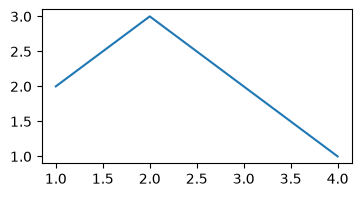

In [150]:
plt.figure(figsize=(4,2))  # 시작점
# figsize

plt.plot([1, 2, 3, 4], [2, 3, 2, 1])

plt.show()    # 마침표

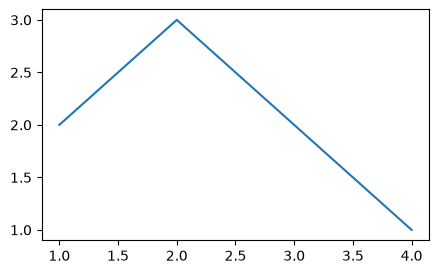

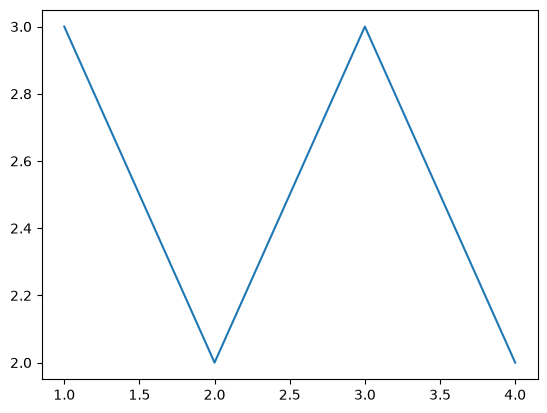

In [151]:
아래 코드를 기반으로 시각화를 더 풍부하고 이쁘게 만들어줘

plt.figure(figsize=(5,3))  # 시작점
# figsize

plt.plot([1, 2, 3, 4], [2, 3, 2, 1])

plt.show()

plt.plot([1,2,3,4],[3,2,3,2])

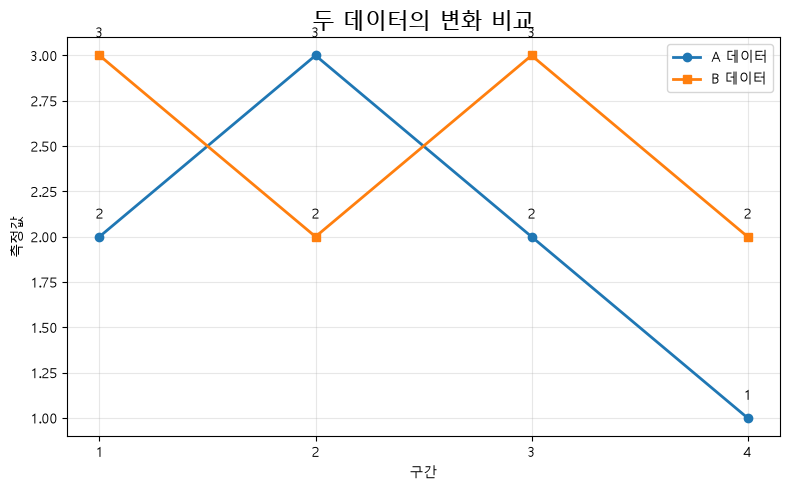

In [154]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

x = [1, 2, 3, 4]
y1 = [2, 3, 2, 1]
y2 = [3, 2, 3, 2]

plt.figure(figsize=(8, 5))

plt.plot(x, y1, marker='o', linewidth=2, label='A 데이터')
plt.plot(x, y2, marker='s', linewidth=2, label='B 데이터')

for i in range(len(x)):
    plt.text(x[i], y1[i] + 0.1, y1[i], ha='center')
    plt.text(x[i], y2[i] + 0.1, y2[i], ha='center')

plt.title('두 데이터의 변화 비교', fontsize=16)
plt.xlabel('구간')
plt.ylabel('측정값')

plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

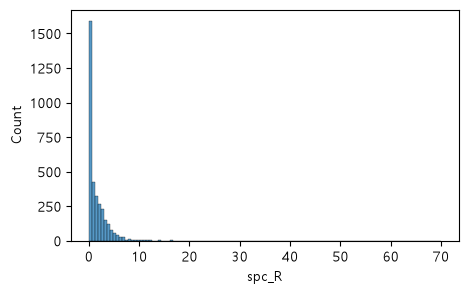

In [156]:
plt.figure(figsize=(5,3))
sns.histplot(total_df, x='spc_R')
plt.show()

## 시각화의 목적 : 이쁜 장표X
- => 데이터를 관찰할 수 있는 유일한 수단
- 데이터 종류에 따라 어떤 시각화를 사용해서 관찰할 것인가를 정리
- 데이터 종류
      - 범주형 데이터
      - 수치형 데이터

### 1. 범주형 데이터
- 카테고리 별로 데이터 어디에 몰려 있고 어떻게 퍼져 있는지 알아보자
- sns.countplot

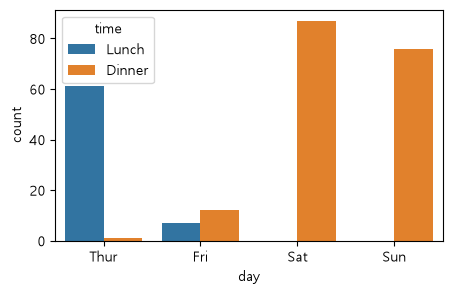

In [160]:
plt.figure(figsize=(5,3))
sns.countplot(tip_df, x = 'day', hue = 'time')
plt.show()

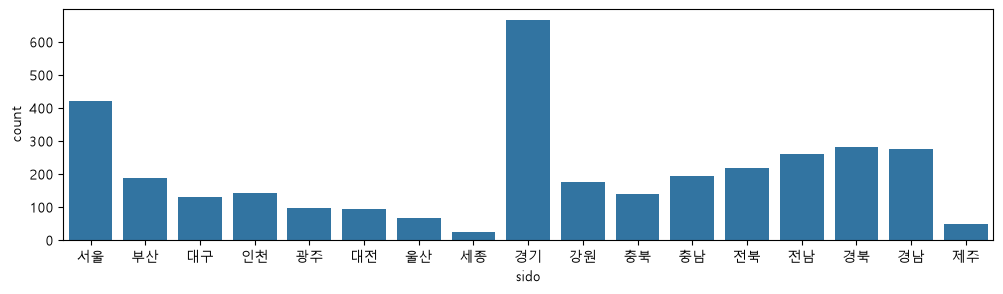

In [162]:
plt.rcParams['font.family'] = 'Malgun Gothic'

# plt.figure(figsize=(5,3))
plt.figure(figsize=(12,3))

sns.countplot(total_df, x='sido')

plt.show()

In [ ]:
범주형

수치형

In [158]:
total_df['name']

0         서울대학교사범대학부설중학교
1       서울대학교사범대학부설여자중학교
2                  개원중학교
3                  경원중학교
4                  구룡중학교
              ...       
3425               오름중학교
3426               탐라중학교
3427              제주영지학교
3428              제주영송학교
3429             서귀포온성학교
Name: name, Length: 3430, dtype: str

### 2. 수치형 데이터
- 어디에 데이터가 몰려있고, 어떻게 퍼져있는지 (분포)
- 히스토그램, sns.histplot( tip_df, x = 'tip')
- plt.show()

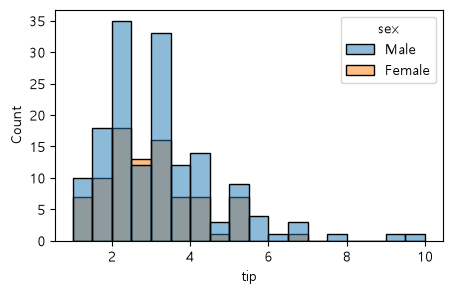

In [165]:
plt.figure(figsize=(5,3))
sns.histplot(tip_df,x='tip',hue='sex')
plt.show()

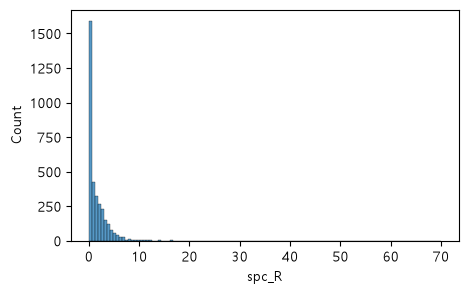

In [163]:
plt.figure(figsize=(5,3))

sns.histplot( total_df, x='spc_R')

plt.show()

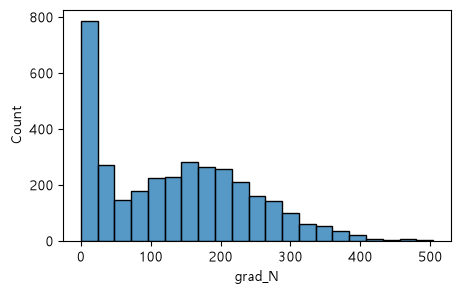

In [167]:
plt.figure(figsize=(5,3))

sns.histplot( total_df, x='grad_N')

plt.show()

# 몰려 있는 곳이 두곳? => 카테고리를 두개로 나눠볼까

In [ ]:
# 졸업생 숫자가 2개의 범주로 나눌 수 있지 않을까?!
# 졸업생이 180정도에 몰려있고 좌우로 퍼져있는 => 대도시
# 졸업생이 10명 미만에 몰려있고 꼬리가 오른쪽으로 긴 => 소도시

In [168]:
total_df['sido'].unique()

<ArrowStringArray>
['서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종', '경기', '강원', '충북', '충남', '전북',
 '전남', '경북', '경남', '제주']
Length: 17, dtype: str

In [171]:
def get_sidoCate(x) :
    if x in ['서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종', '경기']:
        return 'big_city'
    else :
        return 'small_city'


KeyError: 'sido_cate'

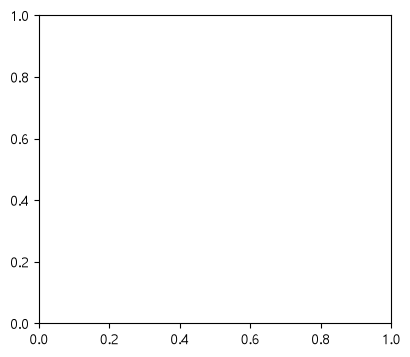

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# big_city
plt.subplot(1, 2, 1)
plt.hist(
    grad_df[grad_df['sido_cate'] == 'big_city']['원하는컬럼'],
    bins=10
)
plt.title('Big City')
plt.xlabel('값')
plt.ylabel('빈도')

# small_city
plt.subplot(1, 2, 2)
plt.hist(
    grad_df[grad_df['sido_cate'] == 'small_city']['원하는컬럼'],
    bins=10
)
plt.title('Small City')
plt.xlabel('값')
plt.ylabel('빈도')

plt.tight_layout()
plt.show()

In [173]:
grad_df.columns

Index(['reg', 'code', 'name', 'grad_N', 'sci_N', 'fl_N', 'spc_N', 'spc_R',
       'sido'],
      dtype='str')